##### 1. import data

In [32]:
import pandas as pd

df = pd.read_csv("./data/urlset.csv",on_bad_lines="skip",dtype="str")

print(df.shape)

(96005, 14)


##### 2. See the columns

In [9]:
df.columns

Index(['domain', 'ranking', 'mld_res', 'mld.ps_res', 'card_rem', 'ratio_Rrem',
       'ratio_Arem', 'jaccard_RR', 'jaccard_RA', 'jaccard_AR', 'jaccard_AA',
       'jaccard_ARrd', 'jaccard_ARrem', 'label'],
      dtype='object')

##### 3. Check the first rows

In [10]:
df.head()

,domain,ranking,mld_res,mld.ps_res,card_rem,ratio_Rrem,ratio_Arem,jaccard_RR,jaccard_RA,jaccard_AR,jaccard_AA,jaccard_ARrd,jaccard_ARrem,label
0,nobell.it/70ffb52d079109dca5664cce6f317373782/...,10000000,1.0,0.0,18,107.611111,107.277778,0,0,0,0,0.8,0.795729,1.0
1,www.dghjdgf.com/paypal.co.uk/cycgi-bin/webscrc...,10000000,0.0,0.0,11,150.636364,152.272727,0,0,0,0,0,0.768577,1.0
2,serviciosbys.com/paypal.cgi.bin.get-into.herf....,10000000,0.0,0.0,14,73.5,72.642857,0,0,0,0,0,0.726582,1.0
3,mail.printakid.com/www.online.americanexpress....,10000000,0.0,0.0,6,562,590.666667,0,0,0,0,0,0.85964,1.0
4,thewhiskeydregs.com/wp-content/themes/widescre...,10000000,0.0,0.0,8,29,24.125,0,0,0,0,0,0.748971,1.0


##### 4. Check missing values

In [13]:
df.isnull().sum()

domain            0
ranking          52
mld_res          70
mld.ps_res       81
card_rem         82
ratio_Rrem       82
ratio_Arem       82
jaccard_RR       83
jaccard_RA       84
jaccard_AR       85
jaccard_AA       86
jaccard_ARrd     86
jaccard_ARrem    88
label            92
dtype: int64

##### 5. Remove rows without a label

In [16]:
df = df.dropna(subset=["label"])

##### 6. Check labels

In [17]:
print(df['label'].value_counts())

label
0.0    48009
1.0    47904
Name: count, dtype: int64


##### 7. Check duplicate URLs

In [19]:
print("Duplicate URLs:",df['domain'].duplicated().sum())

Duplicate URLs: 2


##### 8. Remove Duplicate URLs

In [20]:
df = df.drop_duplicates(subset=["domain"])

##### 9. Check the final dataset

In [21]:
print("Final Shape:",df.shape)
print(df['label'].value_counts())

Final Shape: (95911, 14)
label
0.0    48009
1.0    47902
Name: count, dtype: int64


##### 10. Make 3 simple plots

In [23]:
# pip install matplotlib

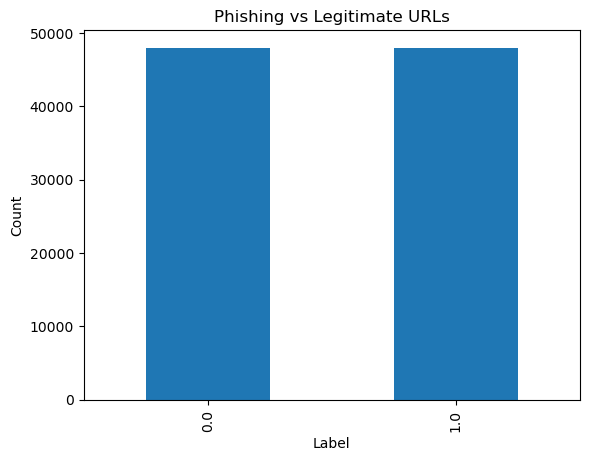

In [25]:
## Class distribution

import matplotlib.pyplot as plt 

df['label'].value_counts().plot(kind="bar")

plt.title("Phishing vs Legitimate URLs")
plt.xlabel("Label")
plt.ylabel("Count")
plt.show()

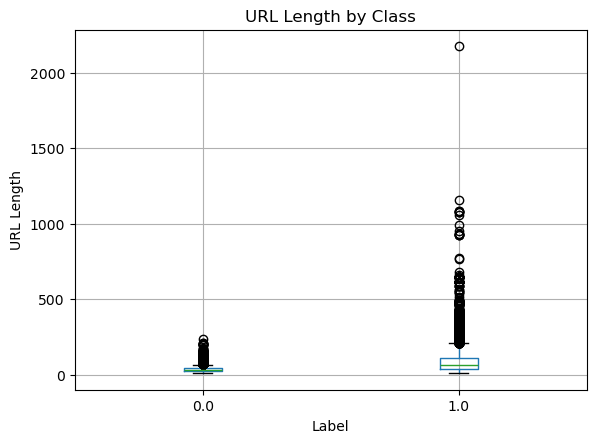

In [30]:
## URL length

df["url_length"] = df["domain"].astype(str).apply(len)


df.boxplot(column="url_length", by="label")

plt.title("URL Length by Class")
plt.suptitle("")
plt.xlabel("Label")
plt.ylabel("URL Length")
plt.show()

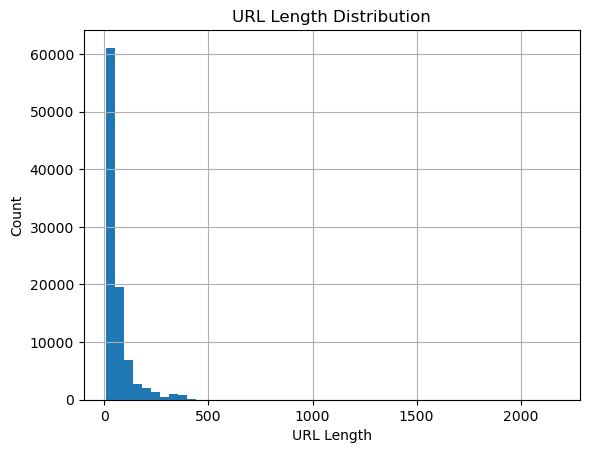

In [31]:
## URL length distribution

df["url_length"].hist(bins=50)

plt.title("URL Length Distribution")
plt.xlabel("URL Length")
plt.ylabel("Count")
plt.show()

#####